# 💎 Jewelry Visual Search Engine
## Tanishq Jewellery Dataset

## 1. Setup

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!pip -q install faiss-cpu torch torchvision pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 69.5 MB/s eta 0:00:00


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import faiss
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms

PROJECT_DIR = "/content/drive/MyDrive/jewelry_search"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
IMAGE_DIR = os.path.join(DATA_DIR, "images", "Jewellery_Data")

os.makedirs(DATA_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Images:", IMAGE_DIR)

Project: /content/drive/MyDrive/jewelry_search
Images: /content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data


## 2. Load the Images

In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

image_paths = []

for root, _, files in os.walk(IMAGE_DIR):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root, file))

image_paths.sort()

print("Number of images:", len(image_paths))

if len(image_paths) == 0:
    raise ValueError("No images found. Check IMAGE_DIR.")

print("\nFirst 5 images:")
for path in image_paths[:5]:
    print(path)

Number of images: 490

First 5 images:
/content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data/necklace/necklace_1.jpg
/content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data/necklace/necklace_10.jpg
/content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data/necklace/necklace_100.jpg
/content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data/necklace/necklace_101.jpg
/content/drive/MyDrive/jewelry_search/data/images/Jewellery_Data/necklace/necklace_102.jpg


## 3. Load MobileNetV2

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Remove the classification layer
model.classifier = nn.Identity()

model = model.to(device)
model.eval()

print("Device:", device)
print("Model loaded successfully")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 107MB/s] 

Device: cpu
Model loaded successfully


## 4. Image Preprocessing

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 5. Extract Image Embeddings

In [8]:
embeddings = []
valid_image_paths = []

with torch.no_grad():
    for image_path in tqdm(image_paths):
        try:
            image = Image.open(image_path).convert("RGB")
            image_tensor = transform(image).unsqueeze(0).to(device)

            embedding = model(image_tensor).cpu().numpy()[0]

            embeddings.append(embedding)
            valid_image_paths.append(image_path)

        except Exception as e:
            print("Skipped:", image_path, "|", e)

embeddings = np.asarray(embeddings, dtype="float32")

if len(embeddings) == 0:
    raise ValueError("No embeddings were created.")

print("Embeddings shape:", embeddings.shape)
print("Valid images:", len(valid_image_paths))

100%|██████████| 490/490 [01:26<00:00,  5.67it/s]

Embeddings shape: (490, 1280)
Valid images: 490


## 6. Build FAISS Index

In [9]:
# Normalize the embeddings for cosine similarity
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("Images in index:", index.ntotal)
print("Embedding dimension:", dimension)

Images in index: 490
Embedding dimension: 1280


## 7. Save Project Files

In [10]:
relative_image_paths = [
    os.path.relpath(path, PROJECT_DIR)
    for path in valid_image_paths
]

EMBEDDINGS_PATH = os.path.join(DATA_DIR, "embeddings.npy")
IMAGE_PATHS_PATH = os.path.join(DATA_DIR, "image_paths.npy")
FAISS_INDEX_PATH = os.path.join(DATA_DIR, "jewelry.index")

np.save(EMBEDDINGS_PATH, embeddings)

np.save(
    IMAGE_PATHS_PATH,
    np.asarray(relative_image_paths, dtype=object)
)

faiss.write_index(index, FAISS_INDEX_PATH)

print("Saved successfully:")
print(EMBEDDINGS_PATH)
print(IMAGE_PATHS_PATH)
print(FAISS_INDEX_PATH)

Saved successfully:
/content/drive/MyDrive/jewelry_search/data/embeddings.npy
/content/drive/MyDrive/jewelry_search/data/image_paths.npy
/content/drive/MyDrive/jewelry_search/data/jewelry.index


## 8. Check Saved Files

In [11]:
print("embeddings.npy exists:", os.path.exists(EMBEDDINGS_PATH))
print("image_paths.npy exists:", os.path.exists(IMAGE_PATHS_PATH))
print("jewelry.index exists:", os.path.exists(FAISS_INDEX_PATH))

print("\nNumber of images:", index.ntotal)

embeddings.npy exists: True
image_paths.npy exists: True
jewelry.index exists: True

Number of images: 490


## 9. Visual Search Test

Saving images (5).jpeg to images (5).jpeg


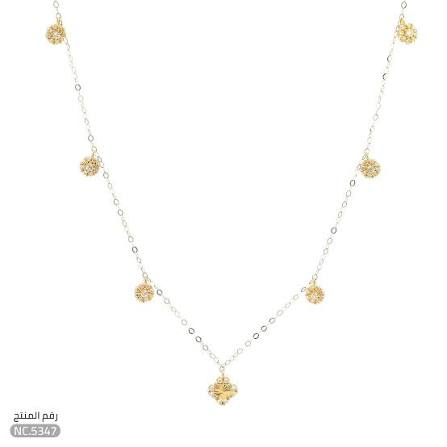

In [13]:
from google.colab import files
import io

uploaded = files.upload()

if not uploaded:
    raise ValueError("No image uploaded.")

uploaded_name = next(iter(uploaded))

query_image = Image.open(
    io.BytesIO(uploaded[uploaded_name])
).convert("RGB")

display(query_image)

## 10. Search for Similar Jewelry

In [14]:
TOP_K = 25

query_tensor = transform(query_image).unsqueeze(0).to(device)

with torch.no_grad():
    query_embedding = model(query_tensor).cpu().numpy().astype("float32")

faiss.normalize_L2(query_embedding)

similarities, indices = index.search(query_embedding, TOP_K)

similarities = similarities[0]
indices = indices[0]

print("Top 25 results found!")

Top 25 results found!


## 11. Display Search Results

Results above threshold: 25


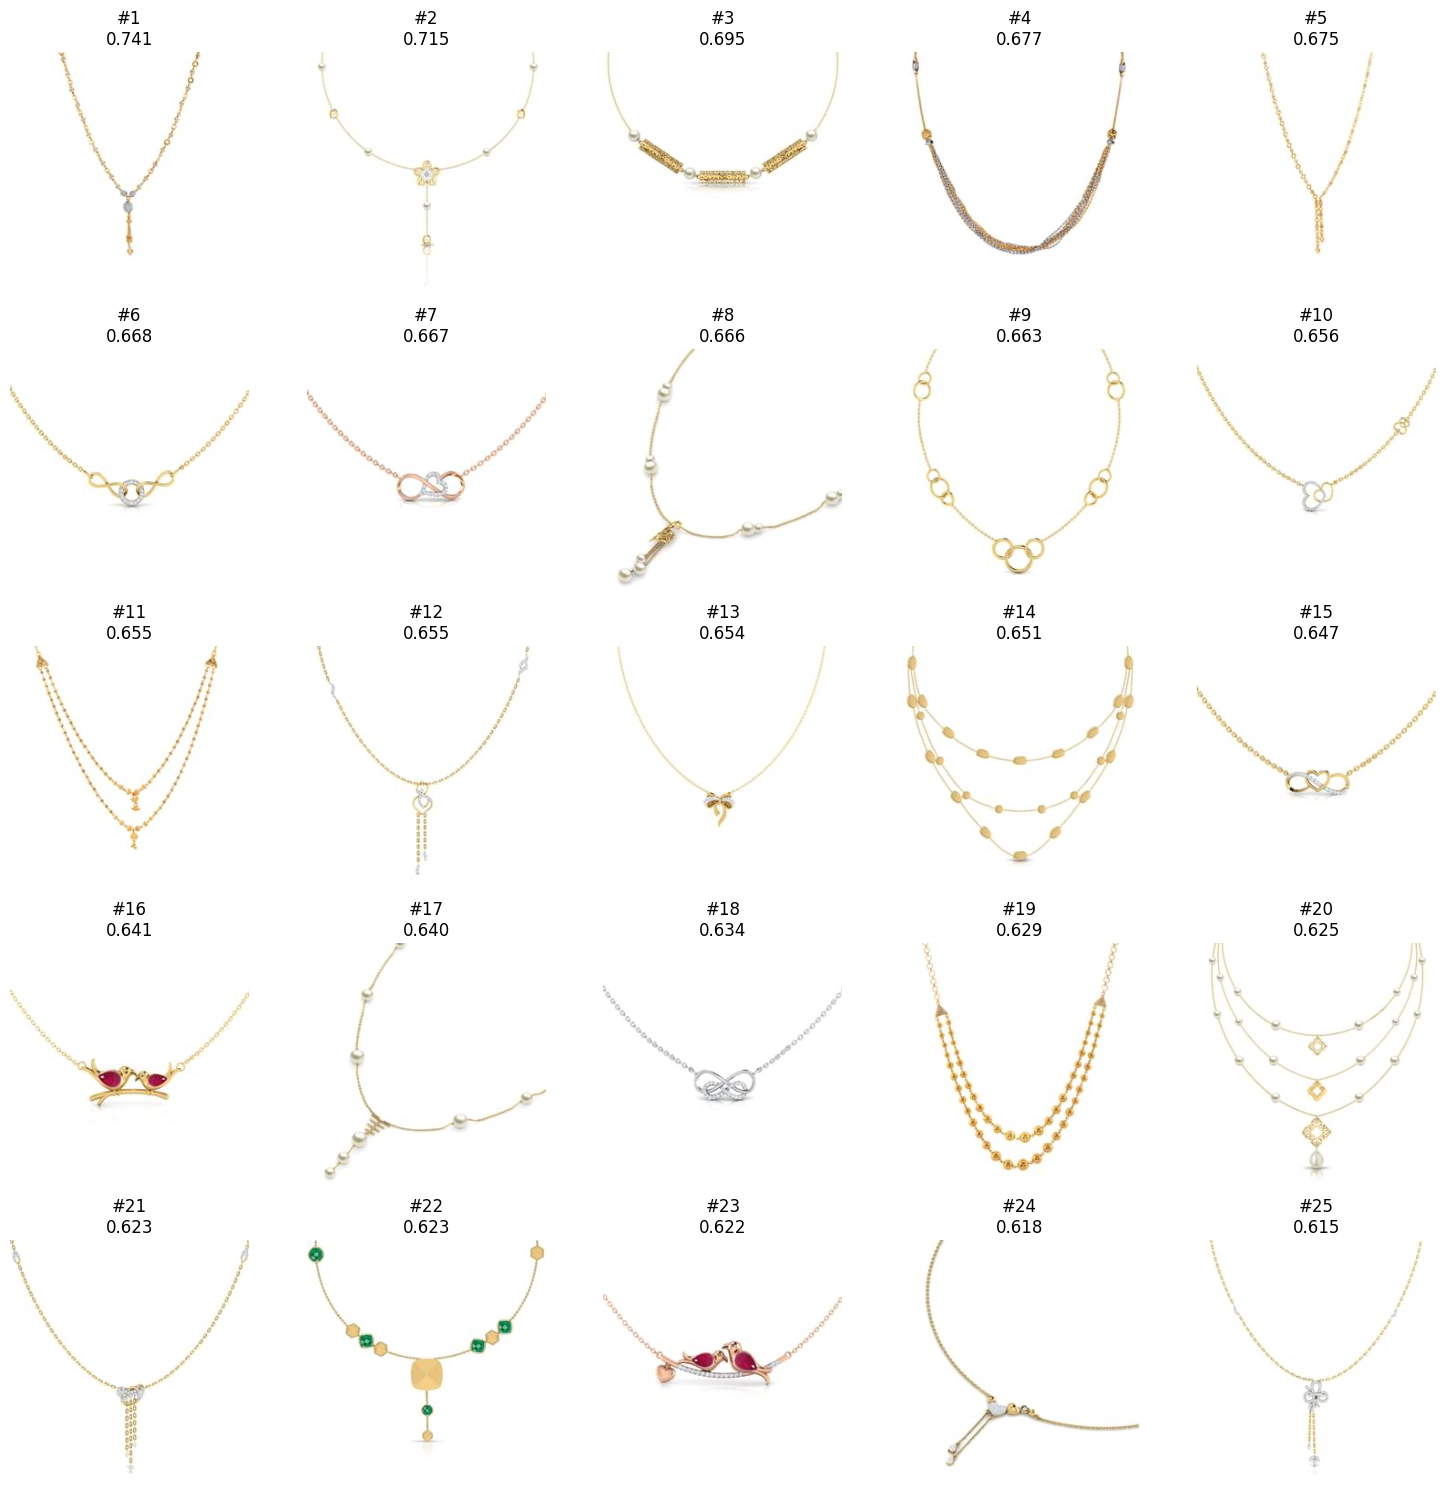

In [15]:
THRESHOLD = 0.55

valid_results = [
    (int(image_index), float(score))
    for image_index, score in zip(indices, similarities)
    if image_index != -1 and score >= THRESHOLD
]

print("Results above threshold:", len(valid_results))

if len(valid_results) == 0:
    print("No results found above the threshold.")
else:
    rows = (len(valid_results) + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(15, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for position, ax in enumerate(axes):
        if position >= len(valid_results):
            ax.axis("off")
            continue

        image_index, score = valid_results[position]
        rel_path = str(relative_image_paths[image_index])
        full_path = os.path.join(PROJECT_DIR, rel_path)

        result_image = Image.open(full_path).convert("RGB")

        ax.imshow(result_image)
        ax.set_title(f"#{position + 1}\n{score:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 12. Quality Check

In [16]:
def category_from_path(path):
    parts = os.path.normpath(path).split(os.sep)
    return parts[-2].lower() if len(parts) >= 2 else "unknown"


# Use one catalog image as a test query
test_index = 0
test_image_path = valid_image_paths[test_index]

test_image = Image.open(test_image_path).convert("RGB")
test_tensor = transform(test_image).unsqueeze(0).to(device)

with torch.no_grad():
    test_embedding = model(test_tensor).cpu().numpy().astype("float32")

faiss.normalize_L2(test_embedding)

# Search for 6 so the query image itself can be removed
test_scores, test_indices = index.search(test_embedding, 6)

test_scores = test_scores[0]
test_indices = test_indices[0]

# Remove the same image from the results
top5_indices = [
    int(i) for i in test_indices
    if int(i) != test_index
][:5]

query_category = category_from_path(relative_image_paths[test_index])

top5_categories = [
    category_from_path(relative_image_paths[i])
    for i in top5_indices
]

precision_at_5 = sum(
    category == query_category
    for category in top5_categories
) / len(top5_categories)

print("Query category:", query_category)
print("Top-5 categories:", top5_categories)
print(f"Category-based Precision@5: {precision_at_5:.2f}")

Query category: necklace
Top-5 categories: ['necklace', 'necklace', 'necklace', 'necklace', 'necklace']
Category-based Precision@5: 1.00


## 13. Reload Test

In [17]:
# This checks that the saved files can be loaded again

loaded_embeddings = np.load(EMBEDDINGS_PATH)

loaded_paths = np.load(
    IMAGE_PATHS_PATH,
    allow_pickle=True
)

loaded_index = faiss.read_index(FAISS_INDEX_PATH)

print("Loaded embeddings:", loaded_embeddings.shape)
print("Loaded paths:", len(loaded_paths))
print("Loaded index images:", loaded_index.ntotal)

Loaded embeddings: (490, 1280)
Loaded paths: 490
Loaded index images: 490
